# Notebook 04 - Importância das variáveis (R² por bloco)

**Pergunta-chave:** se eu fosse um desenvolvedor que só pode escolher **uma** variável para maximizar o salário, qual escolher?

**Estratégia:** rodar uma regressão simples para cada bloco de X (sozinho contra Y) e comparar o R² obtido. O bloco com maior R² é o **X dominante** — aquele que sozinho explica mais da variabilidade salarial.

**Blocos comparados:**
- País (`Country_agrupado`)
- Área de atuação (`DevType_agrupado`)
- Escolaridade (`EdLevel_agrupado`)
- Linguagens (5 dummies `lang_*`)
- Experiência (`YearsCode`, contínua)
- Nível de experiência (`nivel_experiencia`, ordinal)

**Y:** `ConvertedCompYearly` em USD (sem transformação log).

**Saídas:**
- `output/tables/importancia_blocos.csv`
- `output/figures/04_importancia_barras.png`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

PASTA_DADOS = Path('../data/processed')
PASTA_FIGURAS = Path('../output/figures')
PASTA_TABELAS = Path('../output/tables')
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PASTA_DADOS / 'df_limpo.csv')
print(f'Linhas: {len(df):,}')
print(f'Colunas: {df.shape[1]}')
df.head(2)

Linhas: 14,171
Colunas: 18


,ResponseId,MainBranch,EdLevel,Employment,YearsCode,DevType,Country,LanguageHaveWorkedWith,ConvertedCompYearly,Country_agrupado,DevType_agrupado,EdLevel_agrupado,lang_JavaScript,lang_HTML_CSS,lang_SQL,lang_Python,lang_TypeScript,nivel_experiencia
0,1,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",Ukraine,Bash/Shell (all shells);Dart;SQL,61256.0,Outros,mobile,Mestrado,0,0,1,0,0,Senior
1,2,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end",Netherlands,Java,104413.0,Outros,backend,Outros,0,0,0,0,0,Senior


## 1. Definição dos blocos e fórmulas

Cada bloco roda uma regressão **separada** Y ~ X (sem outros controles). Assim o R² obtido representa o quanto aquele bloco **sozinho** explica do salário.

In [ ]:
cols_lang = [c for c in df.columns if c.startswith('lang_')]

blocos = {
    'Pais':              'ConvertedCompYearly ~ C(Country_agrupado)',
    'DevType':           'ConvertedCompYearly ~ C(DevType_agrupado)',
    'Escolaridade':      'ConvertedCompYearly ~ C(EdLevel_agrupado)',
    'Linguagens (top5)': 'ConvertedCompYearly ~ ' + ' + '.join(cols_lang),
    'Experiencia':       'ConvertedCompYearly ~ YearsCode',
    'Nivel_exp':         'ConvertedCompYearly ~ C(nivel_experiencia)',
}

for nome, formula in blocos.items():
    print(f'{nome:22s} -> {formula}')

Pais                   -> ConvertedCompYearly ~ C(Country_agrupado)
DevType                -> ConvertedCompYearly ~ C(DevType_agrupado)
Escolaridade           -> ConvertedCompYearly ~ C(EdLevel_agrupado)
Linguagens (top5)      -> ConvertedCompYearly ~ lang_JavaScript + lang_HTML_CSS + lang_SQL + lang_Python + lang_TypeScript
Experiencia            -> ConvertedCompYearly ~ YearsCode
Nivel_exp              -> ConvertedCompYearly ~ C(nivel_experiencia)


## 2. Estimação de cada bloco

Para cada bloco, ajustamos o OLS e guardamos R², R² ajustado, F e p-valor do F.

In [ ]:
resultados = []
modelos = {}
for nome, formula in blocos.items():
    m = smf.ols(formula, data=df).fit()
    modelos[nome] = m
    resultados.append({
        'Bloco': nome,
        'R2': m.rsquared,
        'R2_ajustado': m.rsquared_adj,
        'F': m.fvalue,
        'p_F': m.f_pvalue,
        'n_params': int(m.df_model),
    })

tabela = pd.DataFrame(resultados).sort_values('R2', ascending=False).reset_index(drop=True)
tabela.to_csv(PASTA_TABELAS / 'importancia_blocos.csv', index=False)

print('Importancia por bloco (ordenado por R2):\n')
print(tabela.to_string(index=False, formatters={
    'R2': '{:.4f}'.format,
    'R2_ajustado': '{:.4f}'.format,
    'F': '{:,.1f}'.format,
    'p_F': '{:.2e}'.format,
}))

Importancia por bloco (ordenado por R2):

            Bloco     R2 R2_ajustado       F       p_F  n_params
             Pais 0.3237      0.3235 1,356.2  0.00e+00         5
      Experiencia 0.1133      0.1133 1,810.8  0.00e+00         1
        Nivel_exp 0.0794      0.0792   610.7 3.78e-255         2
Linguagens (top5) 0.0105      0.0101    30.0  2.05e-30         5
     Escolaridade 0.0100      0.0096    28.6  6.51e-29         5
          DevType 0.0070      0.0067    25.1  1.01e-20         4


## 3. Gráfico-chave: barras de R² por bloco

Este é o gráfico que responde diretamente à pergunta: "qual X tem mais peso para o salário?". A barra mais alta indica o **X dominante**.

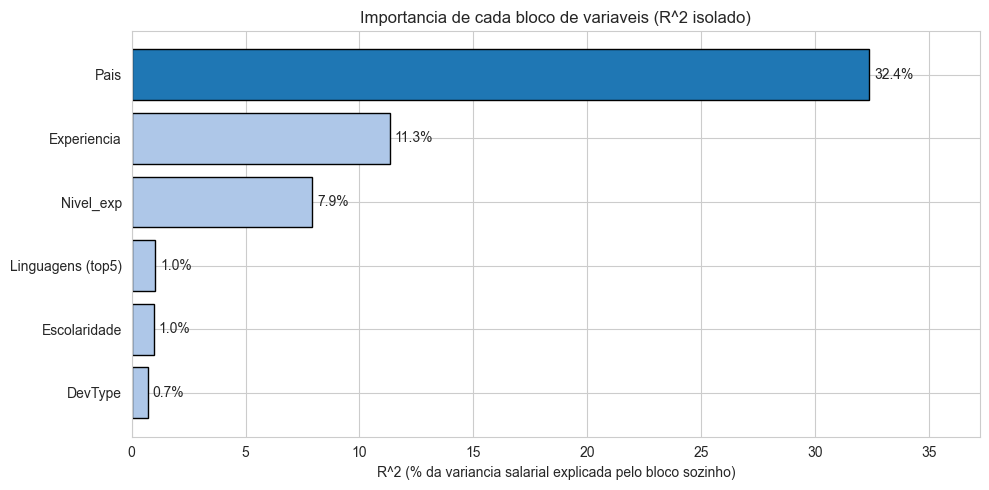

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#1f77b4' if i == 0 else '#aec7e8' for i in range(len(tabela))]
ax.barh(tabela['Bloco'][::-1], tabela['R2'][::-1] * 100, color=cores[::-1], edgecolor='black')
for i, (r2, bloco) in enumerate(zip(tabela['R2'][::-1] * 100, tabela['Bloco'][::-1])):
    ax.text(r2 + 0.2, i, f'{r2:.1f}%', va='center', fontsize=10)
ax.set_xlabel('R² (% da variancia salarial explicada pelo bloco sozinho)')
ax.set_title('Importancia de cada bloco de variaveis (R^2 isolado)')
ax.set_xlim(0, max(tabela['R2'] * 100) * 1.15)
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '04_importancia_barras.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Eleição do X dominante e justificativa

In [ ]:
x_dominante = tabela.iloc[0]['Bloco']
r2_dominante = tabela.iloc[0]['R2']
segundo = tabela.iloc[1]['Bloco']
r2_segundo = tabela.iloc[1]['R2']

print(f'X DOMINANTE: {x_dominante}  (R2 = {r2_dominante:.4f}, ou {r2_dominante*100:.1f}%)')
print(f'Segundo:     {segundo}  (R2 = {r2_segundo:.4f}, ou {r2_segundo*100:.1f}%)')
print(f'Diferenca:   {(r2_dominante - r2_segundo) * 100:.1f} pontos percentuais\n')
print('Conclusao: o bloco eleito sera usado como variavel principal no notebook 05.')
print('YearsCode entrara como controle continuo no modelo focado.')

X DOMINANTE: Pais  (R2 = 0.3237, ou 32.4%)
Segundo:     Experiencia  (R2 = 0.1133, ou 11.3%)
Diferenca:   21.0 pontos percentuais

Conclusao: o bloco eleito sera usado como variavel principal no notebook 05.
YearsCode entrara como controle continuo no modelo focado.


## 5. Síntese

- A comparação R² por bloco substitui a leitura confusa do modelo global anterior (41 variáveis, R² = 0,447 sem ranking claro).
- O bloco vencedor responde direto à pergunta "se eu só puder escolher uma variável, qual leva mais peso para meu salário?".
- O R² absoluto de cada bloco também já antecipa o **teto de explicação possível** com aquela única variável — o restante (1 − R²) é o que outras variáveis (e ruído) ainda têm a explicar.